# 日経平均株価 15分足

In [13]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [14]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [15]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-20 09:00:00+09:00,58821.160156,59012.121094,58687.960938,58784.808594,0,0.0,0.0
2026-04-20 09:15:00+09:00,58776.230469,58918.781250,58769.691406,58865.699219,0,0.0,0.0
2026-04-20 09:30:00+09:00,58863.300781,58908.218750,58786.949219,58904.160156,0,0.0,0.0
2026-04-20 09:45:00+09:00,58908.789062,58980.921875,58887.820312,58973.000000,0,0.0,0.0
2026-04-20 10:00:00+09:00,58973.851562,59056.960938,58891.621094,58919.878906,0,0.0,0.0
2026-04-20 10:15:00+09:00,58924.000000,59023.820312,58889.191406,58948.851562,0,0.0,0.0
2026-04-20 10:30:00+09:00,58949.660156,59055.500000,58919.871094,59034.699219,0,0.0,0.0
2026-04-20 10:45:00+09:00,59029.140625,59106.539062,59013.089844,59092.929688,0,0.0,0.0
2026-04-20 11:00:00+09:00,59086.359375,59088.179688,59043.589844,59066.320312,0,0.0,0.0


In [16]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-04-20 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-04-20 15:30:00+0900', tz='Asia/Tokyo'))

In [17]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-04-13 00:00:00+09:00    56502.769531
2026-04-14 00:00:00+09:00    57877.390625
2026-04-15 00:00:00+09:00    58134.238281
2026-04-16 00:00:00+09:00    59518.339844
2026-04-17 00:00:00+09:00    58475.898438
2026-04-20 00:00:00+09:00    58964.359375
Name: Close, dtype: float64


Date
2026-04-17 00:00:00+09:00    58475.898438
Name: Close, dtype: float64

In [18]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+345.26


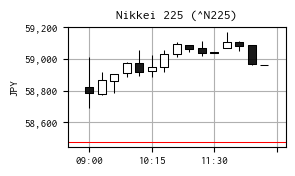

In [19]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [20]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [21]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-17 08:00:00+09:00,159.106995,159.160995,159.095993,159.115005,0,0.0,0.0
2026-04-17 08:15:00+09:00,159.115005,159.128998,159.076004,159.108994,0,0.0,0.0
2026-04-17 08:30:00+09:00,159.108994,159.175995,159.108002,159.156998,0,0.0,0.0
2026-04-17 08:45:00+09:00,159.162994,159.227005,159.149002,159.195007,0,0.0,0.0
2026-04-17 09:00:00+09:00,159.205002,159.263000,159.190994,159.218994,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-20 12:30:00+09:00,158.837006,158.858002,158.789993,158.848007,0,0.0,0.0
2026-04-20 12:45:00+09:00,158.854996,158.886993,158.839996,158.878998,0,0.0,0.0
2026-04-20 13:00:00+09:00,158.876999,158.886002,158.839005,158.863998,0,0.0,0.0


In [22]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-04-20 09:00:00+09:00,369.523751,370.723398,368.686973,369.295385
2026-04-20 09:15:00+09:00,369.499137,370.395288,369.458029,370.061586
2026-04-20 09:30:00+09:00,370.188479,370.470966,369.708307,370.445441
2026-04-20 09:45:00+09:00,370.500187,370.953858,370.368306,370.904034
2026-04-20 10:00:00+09:00,371.012076,371.534928,370.494753,370.672527
2026-04-20 10:15:00+09:00,370.598201,371.226014,370.379275,370.754503
2026-04-20 10:30:00+09:00,371.013922,371.680050,370.826437,371.549135
2026-04-20 10:45:00+09:00,371.598335,372.085571,371.497293,371.999898
2026-04-20 11:00:00+09:00,371.944496,371.955955,371.675265,371.818351


In [23]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-04-17 15:15:00+09:00


np.float64(159.48899841308594)

前日終値（ドル換算） 366.6453424332377


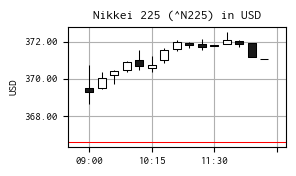

In [24]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()